### Aidan Kaiser
#### Guitar Chord Classification
#### MSDS 561 - Machine Learning

In [1]:
import librosa
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import models, transforms

from model import CustomCNN
from train import run_experiment
from utils import load_audio_dataset, wav_to_melspectrogram
from guitar_chord_dataset import GuitarChordDataset



In [2]:
# load in all the chord .wav into dataframes
train_df = load_audio_dataset("./data/Train")
test_df = load_audio_dataset("./data/Test")

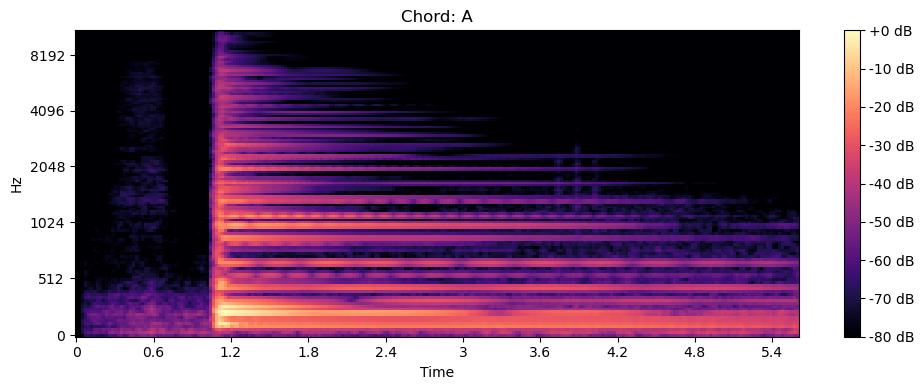

In [3]:
# convert each .wav into a spectrogram image, store in the dataframe
train_df["spectrogram"] = train_df["file_path"].apply(wav_to_melspectrogram)
test_df["spectrogram"] = test_df["file_path"].apply(wav_to_melspectrogram)

# grabs the first chord spectrogram and label
spec = train_df["spectrogram"][0]
label = train_df["label"][0]

# plots the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(spec, x_axis="time", y_axis="mel", sr=22050)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Chord: {label}")
plt.tight_layout()
plt.show()

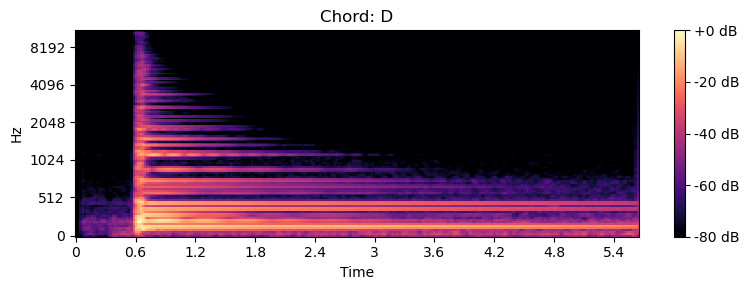

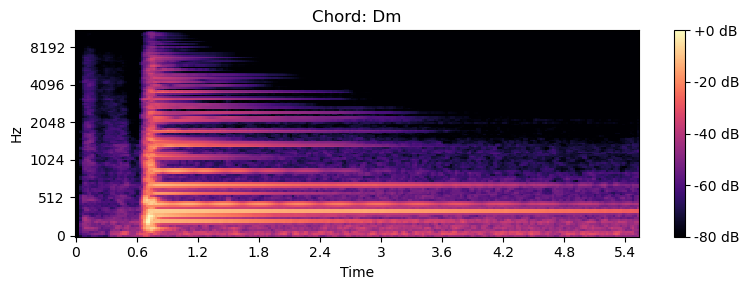

In [4]:
# grabs a D chord spectrogram and label
spec = train_df["spectrogram"][275]
label = train_df["label"][275]

# plots the spectrogram
plt.figure(figsize=(8, 3))
librosa.display.specshow(spec, x_axis="time", y_axis="mel", sr=22050)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Chord: {label}")
plt.tight_layout()
plt.show()

# grabs a Dm chord spectrogram and label
spec = train_df["spectrogram"][350]
label = train_df["label"][350]

# plots the spectrogram
plt.figure(figsize=(8, 3))
librosa.display.specshow(spec, x_axis="time", y_axis="mel", sr=22050)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Chord: {label}")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train_df["label"])


# split train into train/val
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# create datasets
train_dataset = GuitarChordDataset(train_split.reset_index(drop=True), le)
val_dataset   = GuitarChordDataset(val_split.reset_index(drop=True), le)
test_dataset  = GuitarChordDataset(test_df, le)

# create the dataset loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ensures running on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create the custom model
model = CustomCNN(num_layers=2, filters=[32, 64], kernel_sizes=[3, 3],
                  use_pooling=True, dropout=0.5, num_classes=len(le.classes_)
).to(device)

# train the model with the loaders, 30 epochs, and 0.001 learning rate
history = run_experiment(model, train_loader, val_loader, device, num_epochs=30, lr=0.001)

Epoch 01/30 | Train Loss: 3.2323 Acc: 0.089 | Val Loss: 2.9638 Acc: 0.150
  ✓ Saved best model (val_acc=0.150)
Epoch 02/30 | Train Loss: 2.5299 Acc: 0.460 | Val Loss: 1.9259 Acc: 0.638
  ✓ Saved best model (val_acc=0.638)
Epoch 03/30 | Train Loss: 1.3240 Acc: 0.885 | Val Loss: 1.0398 Acc: 0.929
  ✓ Saved best model (val_acc=0.929)
Epoch 04/30 | Train Loss: 0.8945 Acc: 0.964 | Val Loss: 0.9338 Acc: 0.945
  ✓ Saved best model (val_acc=0.945)
Epoch 05/30 | Train Loss: 0.8144 Acc: 0.996 | Val Loss: 0.8755 Acc: 0.969
  ✓ Saved best model (val_acc=0.969)
Epoch 06/30 | Train Loss: 0.7688 Acc: 1.000 | Val Loss: 0.8550 Acc: 0.976
  ✓ Saved best model (val_acc=0.976)
Epoch 07/30 | Train Loss: 0.7439 Acc: 1.000 | Val Loss: 0.8319 Acc: 0.984
  ✓ Saved best model (val_acc=0.984)
Epoch 08/30 | Train Loss: 0.7219 Acc: 1.000 | Val Loss: 0.8186 Acc: 0.969
Epoch 09/30 | Train Loss: 0.7032 Acc: 1.000 | Val Loss: 0.8047 Acc: 0.984
Epoch 10/30 | Train Loss: 0.6890 Acc: 1.000 | Val Loss: 0.8040 Acc: 0.976
E

Test Accuracy: 0.90


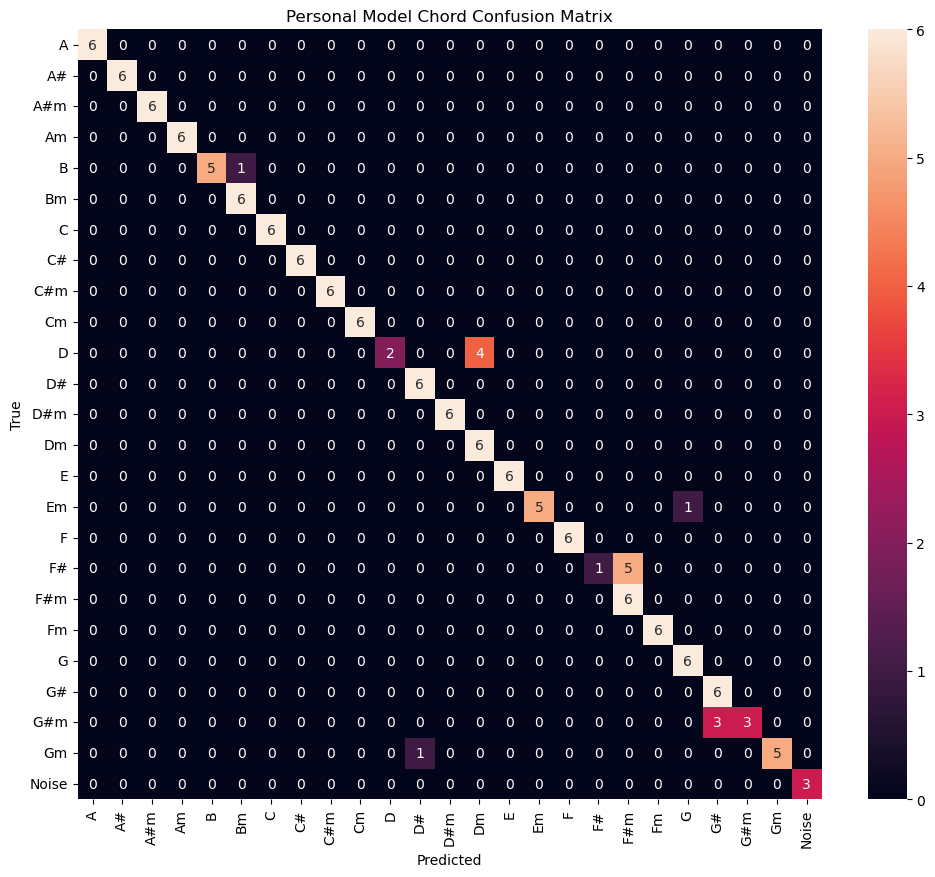

In [6]:
from train import test, get_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# test accuracy
test_acc = test(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.2f}")

# confusion matrix
true_labels, pred_labels = get_predictions(model, test_loader, device)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Personal Model Chord Confusion Matrix")
plt.show()

In [7]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# used to "create" the ResNet-18 model
def build_resnet18(num_classes: int, dropout_rate: float = 0.4) -> nn.Module:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # unfreeze layer3 and layer4 for fine-tuning (final ones)
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    # replace head with dropout and linear matching num_classes
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(model.fc.in_features, num_classes)
    )

    return model


In [8]:
#imagenet normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# preprocessing for ResNet
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

le = LabelEncoder()
le.fit(train_df["label"])
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# augment=True ONLY for training set
train_dataset = GuitarChordDataset(train_split.reset_index(drop=True), le, transform=resnet_transform)
val_dataset = GuitarChordDataset(val_split.reset_index(drop=True), le, transform=resnet_transform, augment=False)
test_dataset = GuitarChordDataset(test_df, le, transform=resnet_transform, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet-18:
pt_model = build_resnet18(num_classes=len(le.classes_), dropout_rate=0.5).to(device)

history = run_experiment( pt_model, train_loader, val_loader, device, num_epochs=30, lr=0.001, weight_decay=1e-3)

Epoch 01/30 | Train Loss: 2.9979 Acc: 0.186 | Val Loss: 2.1791 Acc: 0.496
  ✓ Saved best model (val_acc=0.496)
Epoch 02/30 | Train Loss: 1.3278 Acc: 0.785 | Val Loss: 1.4444 Acc: 0.717
  ✓ Saved best model (val_acc=0.717)
Epoch 03/30 | Train Loss: 0.9745 Acc: 0.935 | Val Loss: 0.8721 Acc: 0.984
  ✓ Saved best model (val_acc=0.984)
Epoch 04/30 | Train Loss: 0.8697 Acc: 0.958 | Val Loss: 0.9193 Acc: 0.945
Epoch 05/30 | Train Loss: 0.8182 Acc: 0.980 | Val Loss: 0.8153 Acc: 0.961
Epoch 06/30 | Train Loss: 0.7786 Acc: 0.998 | Val Loss: 0.7711 Acc: 0.992
  ✓ Saved best model (val_acc=0.992)
Epoch 07/30 | Train Loss: 0.7504 Acc: 0.996 | Val Loss: 0.7406 Acc: 0.992
Epoch 08/30 | Train Loss: 0.7246 Acc: 1.000 | Val Loss: 0.7338 Acc: 1.000
  ✓ Saved best model (val_acc=1.000)
Epoch 09/30 | Train Loss: 0.7243 Acc: 0.996 | Val Loss: 0.7381 Acc: 0.976
Epoch 10/30 | Train Loss: 0.7234 Acc: 1.000 | Val Loss: 0.7329 Acc: 0.992
Epoch 11/30 | Train Loss: 0.7116 Acc: 1.000 | Val Loss: 0.7086 Acc: 1.000
E

Test Accuracy: 0.87


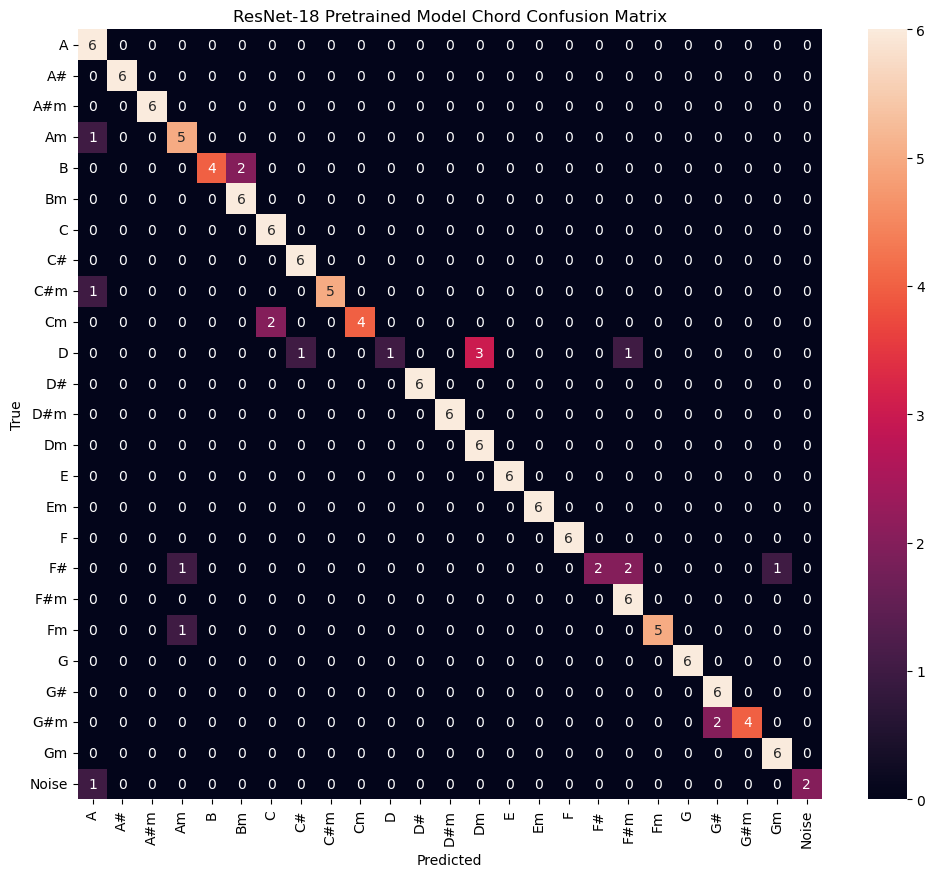

In [9]:
from train import test, get_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# test accuracy
test_acc = test(pt_model, test_loader, device)
print(f"Test Accuracy: {test_acc:.2f}")

# confusion matrix
true_labels, pred_labels = get_predictions(pt_model, test_loader, device)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet-18 Pretrained Model Chord Confusion Matrix")
plt.show()

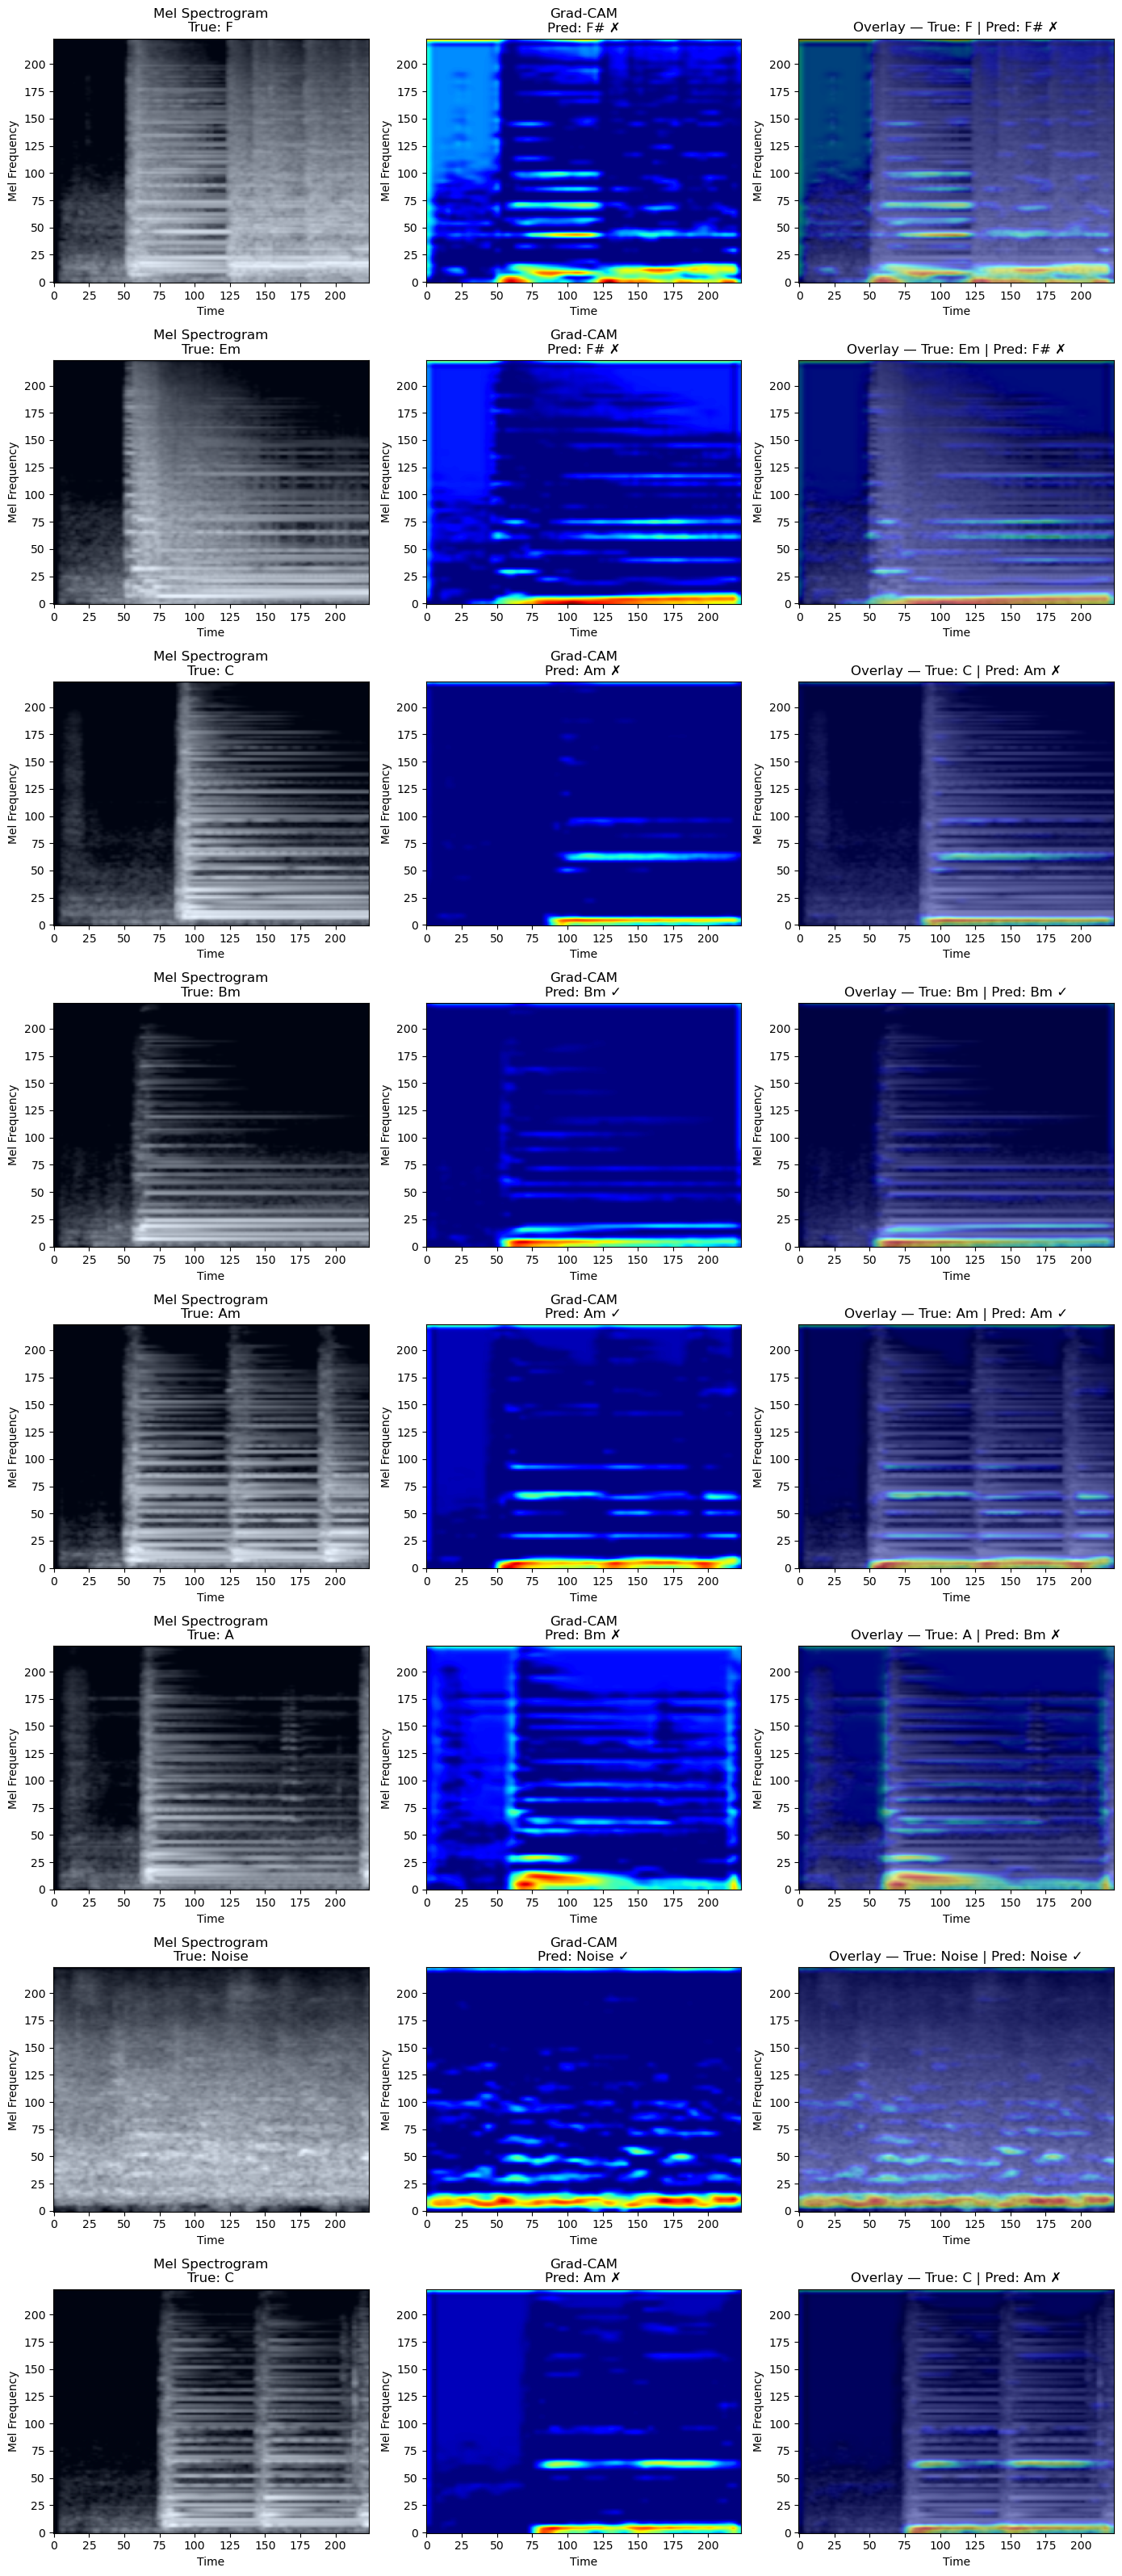

In [10]:
from gradcam import GradCAM, visualize_gradcam_grid
import random

target_layer = model.features[3]
gradcam = GradCAM(model, target_layer)

# produces the plot
random_indices = random.sample(range(len(test_dataset)), k=8)
visualize_gradcam_grid(gradcam, test_dataset, le, device, indices=random_indices)

In [11]:
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=65536, out_features=25, bias=True)
  )
)
